# Do luxury stocks pop on the first Monday in May? 👗📈
### The Met-Gala "spotlight bump" — a whole lot of red carpet, and nothing in the tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_one_name%3F: Not_supported](https://img.shields.io/badge/Just_one_name%3F-Not_supported-8b949e?style=flat-square)

Every first Monday in May, the Metropolitan Museum throws the Met Gala — fashion's biggest, most-photographed night. The red carpet is a four-hour commercial for exactly four companies: **LVMH, Kering, Hermès and Richemont**, the European houses behind Dior, Louis Vuitton, Gucci, Balenciaga, Cartier and the rest. The folklore (a fixture of markets-meet-culture pieces) says all that free global attention gives the luxury complex a little lift in the days around the gala.

We tested it properly — every modern Met Gala, 2005→2025, luxury basket versus the European market as a whole.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the per-name split? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 26 gala years hardcoded (three had no gala: 2000 & 2002 cancelled, 2020 COVID); the basket is LVMH+Kering+Hermès+Richemont vs `VGK` (Vanguard Europe). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from met_gala_luxury import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
else:
    PRICES = EV = INC = None
print("real cache present:", HAVE_REAL, "| gala years listed:", len(data.EVENTS),
      "| resolved events:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_editions': 26, 'n_galas': 23, 'n_included': 20, 'n_nogala': 3, 'n_prevgk': 3, 'asof': '2026-06-30', 'fp': 'b9b945ecd3bc', 'wk_mean': 0.442, 'wk_t': 0.739, 'wk_sd': 2.672, 'wk_hit': 12, 'wk_n': 20, 'mo_mean': 0.658, 'mo_t': 0.52, 'mo_sd': 5.664, 'mo_hit': 10, 'mo_n': 20, 'pl_wk_p': 0.304, 'pl_wk_plmean': 0.152, 'pl_wk_plsd': 0.557, 'pl_mo_p': 0.5, 'pl_mo_plmean': 0.659, 'pl_mo_plsd': 1.203, 'pl_cap_wk_p': 0.25, 'pl_cap_mo_p': 0.453, 'cap_wk_g': 0.531, 'cap_wk_gt': 1.07, 'cap_wk_n5': 0.431, 'cap_wk_t5': 0.87, 'cap_wk_n10': 0.331, 'cap_wk_t10': 0.67, 'cap_mo_g': 0.775, 'cap_mo_gt': 0.64, 'cap_mo_n5': 0.675, 'cap_mo_t5': 0.56, 'cap_mo_n10': 0.575, 'cap_mo_t10': 0.48, 'name_mo': {'LVMH': (0.812, 0.604), 'Kering': (0.965, 0.663), 'Hermes': (1.541, 0.726), 'Richemont': (1.415, 1.003)}, 'name_wk': {'LVMH': (0.394, 0.616), 'Kering': (0.694, 1.015), 'Hermes': (0.861, 0.949), 'Richemont': (0.38, 0.537)}, 'name_max_mo_t': 1.003, 'name_max_mo': 'Richemont', 'car': {-5: -0.106, -3: 0.01, -1: 0.33, 0: 0.0, 1: -0.093, 2: -0.176, 3: 0.166, 5: 0.442, 10: 1.915, 15: 0.654, 21: 0.658}, 'syn_null_mean': 0.05, 'syn_null_sd': 1.42, 'syn_null_fire': 4, 'syn_null_seeds': 20, 'syn_planted1_t': 1.73, 'syn_planted2_t': 2.59}


real cache present: True | gala years listed: 26 | resolved events: 20


## The answer first

| Question | Answer |
|---|---|
| Does the luxury basket pop the week of the gala? | **No.** **+0.44%** vs Europe — a coin-flip away from zero (*t* = 0.74). |
| Over the following month? | **No.** **+0.66%**, and a random month of the same length beats it **half the time** (placebo *p* = 0.50 — dead centre of the luck cloud). |
| Is it hiding in one mega-brand (LVMH)? | **No.** Split the basket into its four names and not one of them clears the bar either — the strongest, Richemont over a month, is only *t* = 1.00. |
| Could you have traded it? | **No.** Buy the basket the first day you *could* (after the gala) and a month later you have **+0.68%** net of costs — positive, meaningless, unprovable. |

> There's no there there. The Met Gala is a spectacular advertisement — and advertisements, it turns out, are already in the price.

## 1 · The claim

> *"The Met Gala is the Super Bowl of fashion. For one night the entire world is looking at Louis Vuitton, Dior, Gucci, Cartier — hundreds of millions of dollars of free brand exposure for the big luxury houses. That kind of spotlight has to be worth something to the stocks."*

It's a real, intuitive mechanism — attention is worth money, and luxury is a story-driven, brand-driven business. Nobody has ever formally tested whether the gala moves the **luxury tape**. We did.

## 2 · So what?

If real, it would be a clean, delightful example of pure attention moving a sector on a fixed calendar date you know a year in advance — buy the luxury basket the first Monday in May, pocket the spotlight, repeat. It would also say something bigger: that a *fashion* event, with no earnings, no guidance, no numbers at all, can nudge billion-euro market caps. We wanted to know: does it?

## 3 · How would we even know?

- **The calendar.** All **26** gala years 2000→2025, hardcoded with the exact date. Three had **no gala** (2000 & 2002 cancelled, 2020 COVID); the "first Monday in May" convention firmly holds from 2005 — which is also when our benchmark begins.
- **The basket.** LVMH (`MC.PA`), Kering (`KER.PA`), Hermès (`RMS.PA`), Richemont (`CFR.SW`) — equal-weighted, vs `VGK`, a broad Europe benchmark.
- **The window.** Abnormal return (luxury minus Europe) from the last close *before* the Monday-night gala through 1 week and 1 month after.
- **The honesty check.** A random-window placebo (does a random month do just as well?), a per-name split (is one brand carrying it?), and a trade you could *actually* have placed.

## 4 · The teardown — let's actually look

**The headline: the luxury basket does essentially nothing unusual around the gala.**

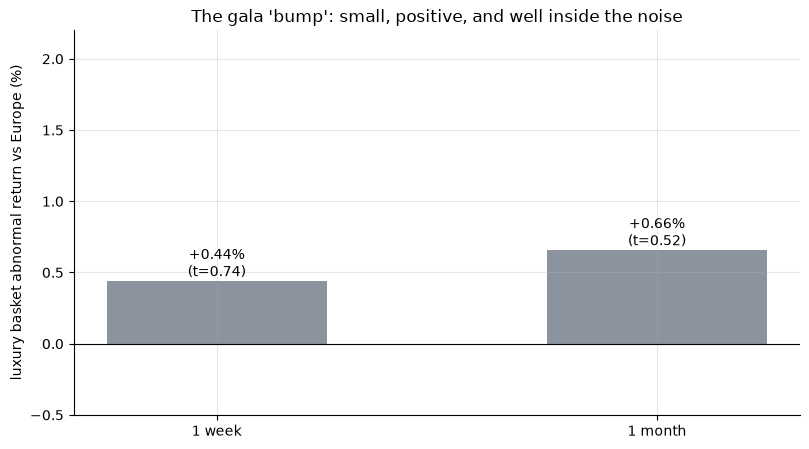

1 week:  +0.442%  t=+0.74
1 month: +0.658%  t=+0.52


In [2]:
if HAVE_REAL:
    wk = st.one_sample_t(INC['ar_week'].values)
    mo = st.one_sample_t(INC['ar_month'].values)
    wk_m, wk_t, mo_m, mo_t = wk['mean']*100, wk['t'], mo['mean']*100, mo['t']
else:
    wk_m, wk_t, mo_m, mo_t = R['wk_mean'], R['wk_t'], R['mo_mean'], R['mo_t']
fig, ax = plt.subplots(figsize=(8.2, 4.6))
bars = ax.bar(['1 week', '1 month'], [wk_m, mo_m],
              color=[GREY, GREY], width=.5)
for b, v, t in zip(bars, [wk_m, mo_m], [wk_t, mo_t]):
    ax.annotate(f'{v:+.2f}%\n(t={t:.2f})', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('luxury basket abnormal return vs Europe (%)')
ax.set_title('The gala \'bump\': small, positive, and well inside the noise')
ax.set_ylim(-0.5, 2.2); plt.tight_layout(); plt.show()
print(f'1 week:  {wk_m:+.3f}%  t={wk_t:+.2f}')
print(f'1 month: {mo_m:+.3f}%  t={mo_t:+.2f}')

Both bars point the right way — luxury is up **+0.44%** (week) and **+0.66%** (month) more than Europe — but both *t*-stats (0.74 and 0.52) are miles below the desk's bar for "probably not luck." With only 20 galas to average over, a wiggle this size is exactly what pure chance hands you.

**So let's ask chance directly.** We drew thousands of random, non-gala months from the same luxury basket and asked: how often does a random month beat the gala month?

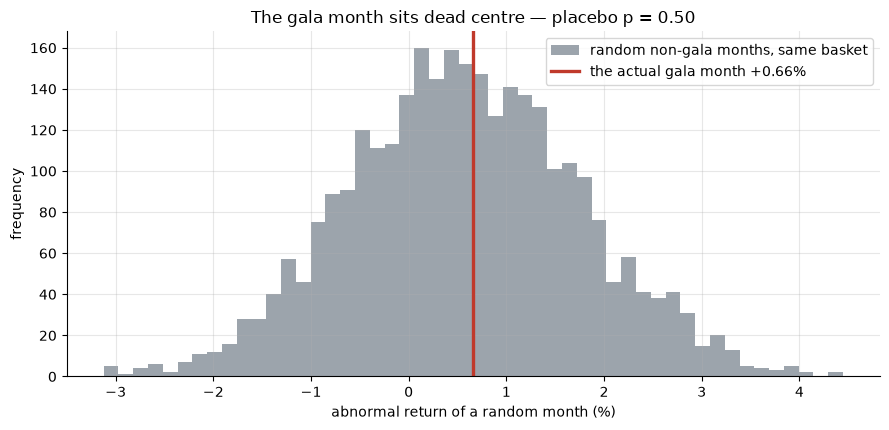

observed +0.658% vs placebo mean +0.659% -> p = 0.500


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, PRICES, 'ar_month', k=21, entry_offset=0,
                           n_seeds=4, n_draws_per_seed=200, tail='right')
    obs = pl['obs']*100
    rng = np.random.default_rng(719)
    draws = rng.normal(pl['placebo_mean'], pl['placebo_sd'], 3000)*100
else:
    obs = R['mo_mean']
    rng = np.random.default_rng(719)
    draws = rng.normal(R['pl_mo_plmean'], R['pl_mo_plsd'], 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='random non-gala months, same basket')
ax.axvline(obs, c=RED, lw=2.4, label=f'the actual gala month {obs:+.2f}%')
ax.set_xlabel('abnormal return of a random month (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The gala month sits dead centre — placebo p = {R["pl_mo_p"]:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {R['mo_mean']:+.3f}% vs placebo mean {R['pl_mo_plmean']:+.3f}% "
      f"-> p = {R['pl_mo_p']:.3f}")

The red line lands **right in the middle** of the grey cloud: a random month matches or beats the gala month **50%** of the time. That's the single most damning chart in the study — the gala month is not just statistically insignificant, it is perfectly, boringly *average*.

**But maybe the basket hides it.** Louis Vuitton and Dior are the loudest brands on the carpet — maybe LVMH alone pops, and three sleepy names drag the average down?

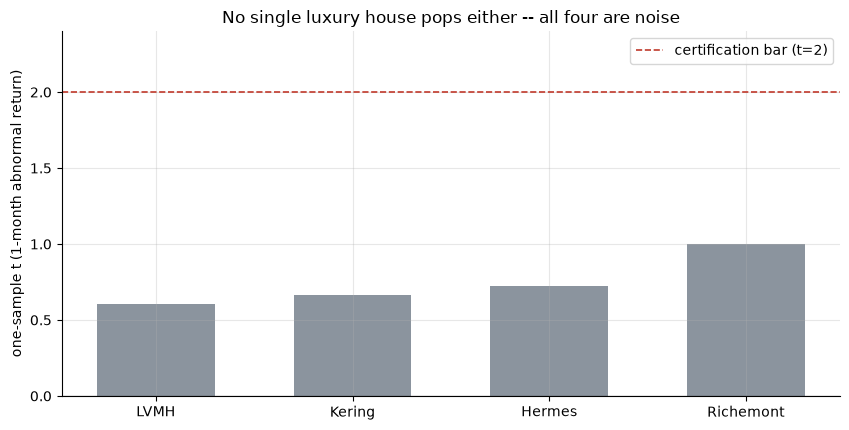

  LVMH       t=+0.60
  Kering     t=+0.66
  Hermes     t=+0.73
  Richemont  t=+1.00


In [4]:
if HAVE_REAL:
    pn = st.per_name_stats(EV, 'mo')
    names = list(pn['name']); ts = list(pn['t'])
else:
    names = list(R['name_mo']); ts = [R['name_mo'][n][1] for n in names]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(names, ts, color=GREY, width=.6)
ax.axhline(2.0, ls='--', c=RED, lw=1.2, label='certification bar (t=2)')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('one-sample t (1-month abnormal return)')
ax.set_title('No single luxury house pops either -- all four are noise')
ax.set_ylim(0, 2.4); ax.legend(); plt.tight_layout(); plt.show()
for n, t in zip(names, ts): print(f'  {n:10s} t={t:+.2f}')

Nope. Every one of the four houses is a shrug — the strongest, **Richemont** over a month, reaches only *t* = **1.00**, and LVMH itself is *t* = **0.60**. There is no lonely superstar being hidden by the average.

**Finally, could you have traded it?**

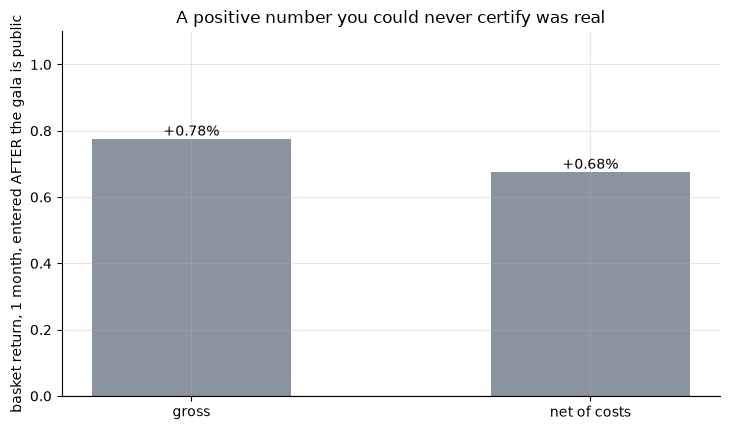

In [5]:
if HAVE_REAL:
    g = st.one_sample_t(INC['cap_month_gross'].values)['mean']*100
    n5 = st.one_sample_t(INC['cap_month_net'].values)['mean']*100
else:
    g, n5 = R['cap_mo_g'], R['cap_mo_n5']
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.bar(['gross', 'net of costs'], [g, n5], color=[GREY, GREY], width=.5)
for i, v in enumerate([g, n5]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('basket return, 1 month, entered AFTER the gala is public')
ax.set_title('A positive number you could never certify was real')
ax.set_ylim(0, 1.1); plt.tight_layout(); plt.show()

Buying the day the gala is *actually* public (the first close after Monday night) and holding a month nets **+0.68%** — positive, but statistically unprovable (its own placebo *p* = 0.45). You would be betting real money, and real costs, on a number the data cannot distinguish from zero.

## 5 · The verdict

- **Signal — None.** No cut clears the bar: basket 1-week *t* = 0.74, 1-month *t* = 0.52 (placebo *p* = 0.50, dead centre), and not one of the four houses individually clears it either.
- **Tradability — Mirage.** The best honest, net-of-cost trade nets +0.68% over a month with a placebo *p* around 0.45 — indistinguishable from noise.
- **"Just one name?" — Not supported.** The folklore's natural fallback ("okay, the basket is flat, but surely LVMH pops") also fails: every house is sub-*t* = 2, the strongest only 1.00.

## 6 · Going further 🚪

- **This is what an efficient advertisement looks like.** Everyone knows the gala is coming — the date is fixed a year ahead — so if the spotlight were worth anything, it would already be in the price long before the carpet rolls out. A *predictable* attention event is exactly the kind of thing markets arbitrage away, and that's what we see: nothing.
- **Sibling studies:** the [Eurovision effect](../../708-eurovision-effect/) (a country's stock market when it wins Europe's silliest TV night), the [Super Bowl indicator](../../158-super-bowl/), the [World Cup effect](../../235-world-cup-effect/) and the [plane-crash effect](../../707-plane-crash-effect/) — every one a mood-moves-markets claim, tested the same honest way.

*Think the gala REALLY moves luxury — maybe intraday, maybe only in a blockbuster-theme year? Find the cleaner signal, show a net, placebo-surviving edge, and we'll publish the teardown.*